In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


 VPP AGGREGATION & MULTI-ASSET DISPATCH OPTIMIZER (GERMAN SPOT DA)
Unoptimized Baseline Daily Profit:    €2,171.08
Optimal MILP Daily Profit:           €2,827.47
Realized Profit (with SCADA Drops):  €2,760.30
---------------------------------------------------------------------------
Net Optimization Uplift Generated:   €589.22 / day
SCADA Telemetry Loss Drag:          -€67.17 / day


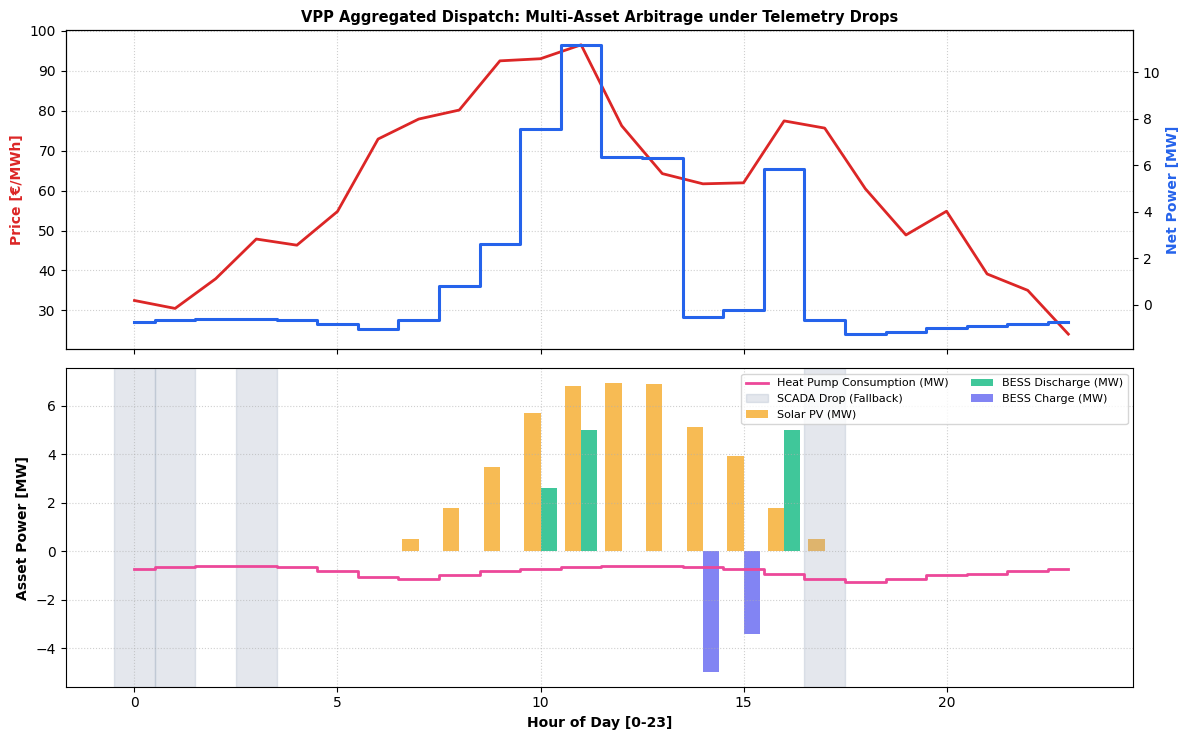

File 'vpp_dispatch_optimization_results.csv' saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog

# ==========================================================
# 1. MARKET PRICES & HETEROGENEOUS ASSET SPECIFICATIONS (24h)
# ==========================================================
np.random.seed(42)
HOURS = 24
h_arr = np.arange(HOURS)

# Day-Ahead Spot Price Profile [€/MWh] with morning & evening peaks
spot_prices_eur = 65.0 + 35.0 * np.sin(2 * np.pi * (h_arr - 6) / 24) + np.random.normal(0, 5.0, HOURS)
spot_prices_eur[12:16] -= 25.0  # Midday solar dip

# Asset 1: Utility-Scale BESS (5 MW / 10 MWh, 90% roundtrip efficiency)
BESS_MAX_POWER_MW = 5.0
BESS_CAPACITY_MWH = 10.0
BESS_ETA = 0.9486  # sqrt(0.90) for one-way efficiency
BESS_C_RATE_DEGRADATION_COST = 3.0  # €/MWh throughput cost

# Asset 2: Industrial Heat Pump (2 MW Electric max, flexible thermal buffer)
HP_ELEC_MAX_MW = 2.5
HP_MIN_RUN_MW = 0.2
THERMAL_DEMAND_MWTH = np.array([
    2.2, 2.0, 1.8, 1.8, 2.0, 2.5, 3.2, 3.5, 3.0, 2.5, 2.2, 2.0,
    1.8, 1.8, 2.0, 2.2, 2.8, 3.5, 3.8, 3.5, 3.0, 2.8, 2.5, 2.2
])
COP = 3.0
HP_BASE_ELEC_DEMAND = THERMAL_DEMAND_MWTH / COP

# Asset 3: Commercial Solar PV (8 MWp Rooftop)
solar_profile = np.sin(np.pi * np.clip(h_arr - 6, 0, 12) / 12) ** 2
PV_GEN_MW = 8.0 * solar_profile * np.random.uniform(0.85, 1.0, HOURS)

# Telemetry Signal Availability (Simulating SCADA signal dropouts)
telemetry_availability = np.random.choice([1.0, 0.0], size=HOURS, p=[0.85, 0.15])

# ==========================================================
# 2. LINEAR PROGRAMMING DISPATCH FORMULATION
# ==========================================================
# Variables per hour: [P_ch[t], P_dis[t], SoC[t], P_hp[t]] -> Total: 4 * 24 = 96
num_vars = 4 * HOURS
c = np.zeros(num_vars)

for t in range(HOURS):
    c[t] = spot_prices_eur[t] + BESS_C_RATE_DEGRADATION_COST  # Charge cost
    c[HOURS + t] = -spot_prices_eur[t]                        # Discharge revenue
    c[2 * HOURS + t] = 0.0                                    # SoC tracking
    c[3 * HOURS + t] = spot_prices_eur[t]                     # Heat pump power cost

# Equality Constraints (A_eq, b_eq): BESS SoC dynamics
# SoC[t] - SoC[t-1] - eta*P_ch[t] + (1/eta)*P_dis[t] = 0
A_eq = np.zeros((HOURS, num_vars))
b_eq = np.zeros(HOURS)

for t in range(HOURS):
    A_eq[t, 2 * HOURS + t] = 1.0
    A_eq[t, t] = -BESS_ETA
    A_eq[t, HOURS + t] = 1.0 / BESS_ETA
    if t > 0:
        A_eq[t, 2 * HOURS + (t - 1)] = -1.0
    else:
        b_eq[0] = 0.5 * BESS_CAPACITY_MWH  # Initial SoC = 50%

# Inequality Constraints (A_ub, b_ub): Heat Pump electricity >= Base Demand
A_ub = np.zeros((HOURS, num_vars))
b_ub = np.zeros(HOURS)
for t in range(HOURS):
    A_ub[t, 3 * HOURS + t] = -1.0
    b_ub[t] = -HP_BASE_ELEC_DEMAND[t]

# Variable Bounds
bounds = []
for t in range(HOURS):
    bounds.append((0.0, BESS_MAX_POWER_MW))                        # P_ch
for t in range(HOURS):
    bounds.append((0.0, BESS_MAX_POWER_MW))                        # P_dis
for t in range(HOURS):
    bounds.append((0.1 * BESS_CAPACITY_MWH, 0.9 * BESS_CAPACITY_MWH))  # SoC (10%-90%)
for t in range(HOURS):
    bounds.append((HP_MIN_RUN_MW, HP_ELEC_MAX_MW))                # P_hp

# Solve LP
res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")

if not res.success:
    raise RuntimeError(f"Optimization failed: {res.message}")

# Extract Optimal Dispatch Schedule
p_charge_opt = res.x[:HOURS]
p_discharge_opt = res.x[HOURS:2*HOURS]
soc_opt = res.x[2*HOURS:3*HOURS]
p_hp_opt = res.x[3*HOURS:4*HOURS]

# Net VPP Generation
vpp_net_export_opt = PV_GEN_MW + p_discharge_opt - p_charge_opt - p_hp_opt

# Fallback on Telemetry Loss
p_charge_actual = np.where(telemetry_availability == 1.0, p_charge_opt, 0.0)
p_discharge_actual = np.where(telemetry_availability == 1.0, p_discharge_opt, 0.0)
p_hp_actual = np.where(telemetry_availability == 1.0, p_hp_opt, HP_BASE_ELEC_DEMAND)
vpp_net_export_actual = PV_GEN_MW + p_discharge_actual - p_charge_actual - p_hp_actual

# Financial Results
optimal_daily_profit_eur = np.sum(vpp_net_export_opt * spot_prices_eur)
actual_daily_profit_eur = np.sum(vpp_net_export_actual * spot_prices_eur)
unoptimized_baseline_profit = np.sum((PV_GEN_MW - HP_BASE_ELEC_DEMAND) * spot_prices_eur)

milp_uplift_eur = actual_daily_profit_eur - unoptimized_baseline_profit
telemetry_drag_eur = optimal_daily_profit_eur - actual_daily_profit_eur

print("=" * 75)
print(" VPP AGGREGATION & MULTI-ASSET DISPATCH OPTIMIZER (GERMAN SPOT DA)")
print("=" * 75)
print(f"Unoptimized Baseline Daily Profit:    €{unoptimized_baseline_profit:,.2f}")
print(f"Optimal MILP Daily Profit:           €{optimal_daily_profit_eur:,.2f}")
print(f"Realized Profit (with SCADA Drops):  €{actual_daily_profit_eur:,.2f}")
print("-" * 75)
print(f"Net Optimization Uplift Generated:   €{milp_uplift_eur:,.2f} / day")
print(f"SCADA Telemetry Loss Drag:          -€{telemetry_drag_eur:,.2f} / day")
print("=" * 75)

# ==========================================================
# 3. VISUALIZATION & CSV EXPORT
# ==========================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True)

# Subplot 1: Prices & Net Export
ax1.plot(h_arr, spot_prices_eur, color="#DC2626", lw=2.0, label="Spot DA Price (€/MWh)")
ax1.set_ylabel("Price [€/MWh]", color="#DC2626", fontweight="bold")
ax1.grid(True, linestyle=":", alpha=0.6)

ax1_twin = ax1.twinx()
ax1_twin.step(h_arr, vpp_net_export_actual, where="mid", color="#2563EB", lw=2.2, label="Realized Net VPP Export (MW)")
ax1_twin.set_ylabel("Net Power [MW]", color="#2563EB", fontweight="bold")
ax1.set_title("VPP Aggregated Dispatch: Multi-Asset Arbitrage under Telemetry Drops", fontsize=10.5, fontweight="bold")

# Subplot 2: Asset Stack
ax2.bar(h_arr - 0.2, PV_GEN_MW, width=0.4, color="#F59E0B", alpha=0.7, label="Solar PV (MW)")
ax2.bar(h_arr + 0.2, p_discharge_actual, width=0.4, color="#10B981", alpha=0.8, label="BESS Discharge (MW)")
ax2.bar(h_arr + 0.2, -p_charge_actual, width=0.4, color="#6366F1", alpha=0.8, label="BESS Charge (MW)")
ax2.step(h_arr, -p_hp_actual, where="mid", color="#EC4899", lw=2.0, label="Heat Pump Consumption (MW)")

drop_hours = np.where(telemetry_availability == 0.0)[0]
for dh in drop_hours:
    ax2.axvspan(dh - 0.5, dh + 0.5, color="#94A3B8", alpha=0.25, label="SCADA Drop (Fallback)" if dh == drop_hours[0] else "")

ax2.set_xlabel("Hour of Day [0-23]", fontweight="bold")
ax2.set_ylabel("Asset Power [MW]", fontweight="bold")
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="upper right", frameon=True, fontsize=8.0, ncol=2)

plt.tight_layout()
plt.savefig("vpp_dispatch_optimization.png", dpi=300)
plt.show()

# CSV Export
df_vpp = pd.DataFrame({
    "hour": h_arr,
    "spot_price_eur": spot_prices_eur,
    "pv_gen_mw": PV_GEN_MW,
    "bess_charge_mw": p_charge_actual,
    "bess_discharge_mw": p_discharge_actual,
    "bess_soc_mwh": soc_opt,
    "hp_elec_mw": p_hp_actual,
    "vpp_net_export_mw": vpp_net_export_actual,
    "scada_available": telemetry_availability
})
csv_filename = "vpp_dispatch_optimization_results.csv"
df_vpp.to_csv(csv_filename, index=False)
print(f"File '{csv_filename}' saved successfully.")

try:
    from google.colab import files
    files.download(csv_filename)
except ImportError:
    pass